Today's topics:
* `matplotlib`, properly this time: `fig, ax = plt.subplots()`
* `ax.scatter`, `ax.plot`, `ax.hist` -- and how to pick the right one
* labels, titles, legends, multi-panel figures, and saving your work

> By the end of today you should be able to complete Problems 1-4 of Homework 4

# Every plot answers a question

*What question are you trying to answer?* Say it out loud before you type a line of `matplotlib`.

A chart needs a **title**, axis labels **with units**, and a **legend** to actually communicate. No labels, no title → just pixels.

# Load the dataset

## Dataset: Periodic Table Properties

This dataset contains basic physical and chemical properties of chemical elements
from the periodic table, including standard atomic weight, density, atomic radius,
electronegativity, melting point, and crystal structure.

Columns include: `Element`, `Standard Atomic Weight`, `Density (g/cm^3)`,
`Atomic Radius`, `Electronegativity`, `Melting Point`, `Structure`, and others.

In [1]:
import os
import pandas as pd

_file = 'periodic_table.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data

,Element,Standard Atomic Weight,Atomic Radius,Structure,Electronegativity,Valence,Melting Point (K),Density (g/cm^3),Heat of Fusion (kJ/mol),Molar Heat Capacity (J/mol*K),Young's Modulus (GPa),Poisson Ratio
0,Cu,63.5460,0.128 nm,FCC,1.8,2+,1357.7700,8.960,13.260,24.440,119.0,0.340
1,Ni,58.6934,0.125 nm,FCC,1.8,2+,1728.0000,8.908,17.480,26.070,200.0,0.310
2,Al,26.9810,0.143 nm,FCC,1.5,3+,933.4700,2.700,10.710,24.200,70.0,0.350
3,Zn,65.3800,0.133 nm,HCP,1.7,2+,692.6800,7.140,7.320,25.470,108.0,0.250
4,Pb,207.2000,0.175 nm,FCC,1.6,2+,600.6100,11.340,4.770,26.650,16.0,0.440
5,Sc,44.9550,0.162 nm,HCP,1.4,2+,1814.0000,2.985,14.100,25.520,74.4,0.279
6,Ti,47.8670,0.147 nm,HCP,1.5,4+,1941.0000,4.506,14.150,25.060,116.0,0.320
7,V,50.9415,0.134 nm,BCC,1.6,5+,2183.0000,6.110,21.500,24.890,128.0,0.370
8,Cr,51.9961,0.128 nm,BCC,1.7,6+,2180.0000,7.190,21.000,23.350,279.0,0.210
9,Ga,69.7230,0.135 nm,ORTHO,1.8,3+,302.9146,5.910,5.590,25.860,9.8,0.470


Same periodic table from Lecture 8 — 14 metallic elements: density, melting point, Young's Modulus, electronegativity, crystal structure.

# Your first real scatter plot

*Do stiffer metals also have higher melting points?* "Stiffer" = higher Young's Modulus.

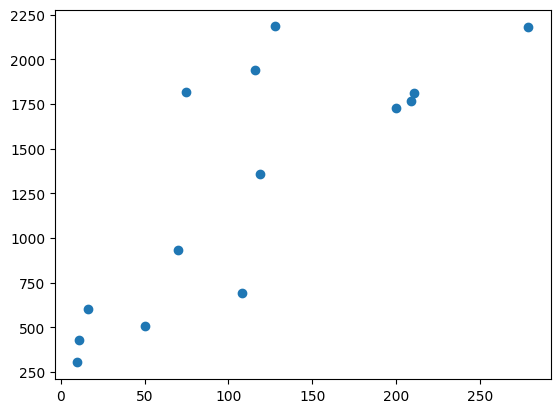

In [2]:
import matplotlib.pyplot as plt

plt.scatter(data["Young's Modulus (GPa)"], data['Melting Point (K)'])
plt.show()

No units, no labels, no title — what question does this even answer?

The idiom from here on: `fig` (the canvas) and `ax` (one set of axes), methods on `ax` — pays off the moment we want more than one panel.

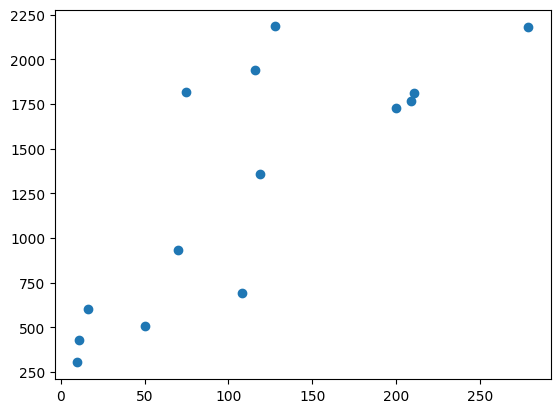

In [3]:
fig, ax = plt.subplots()
ax.scatter(data["Young's Modulus (GPa)"], data['Melting Point (K)'])
plt.show()

Same picture, different plumbing. Column names *are* the label text — copy them in:

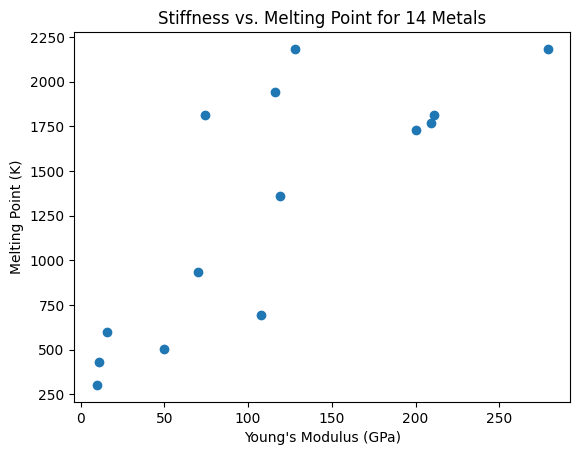

In [4]:
fig, ax = plt.subplots()
ax.scatter(data["Young's Modulus (GPa)"], data['Melting Point (K)'])
ax.set_xlabel("Young's Modulus (GPa)")
ax.set_ylabel('Melting Point (K)')
ax.set_title('Stiffness vs. Melting Point for 14 Metals')
plt.show()

Points climb loosely up and to the right — stiffer metals tend to melt hotter. One point sits well off the pattern; we're not chasing it down today.

> **Read more:** [PDSH — Simple Scatter Plots](https://jakevdp.github.io/PythonDataScienceHandbook/04.02-simple-scatter-plots.html)

### [Check your understanding]

In the code cell below, build a `fig, ax` scatter plot of `data['Density (g/cm^3)']` (x-axis) against
`data["Young's Modulus (GPa)"]` (y-axis), with `set_xlabel`, `set_ylabel`, and a `set_title` that states the
question the plot is answering.

# Line vs. scatter: matching plot type to question

`ax.plot` connects points with a line, in row order. Same data, no other changes:

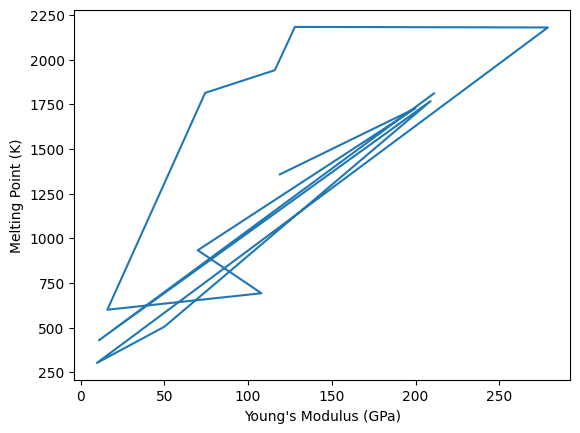

In [5]:
fig, ax = plt.subplots()
ax.plot(data["Young's Modulus (GPa)"], data['Melting Point (K)'])
ax.set_xlabel("Young's Modulus (GPa)")
ax.set_ylabel('Melting Point (K)')
plt.show()

*Same 14 numbers — why does it look like static?*

`ax.plot` connects row 1→2→3→... in table order — not sorted by stiffness or anything meaningful. Order of x-values has to *mean* something for a line to make sense.

Compare a case where it does — a swept variable, computed in order:

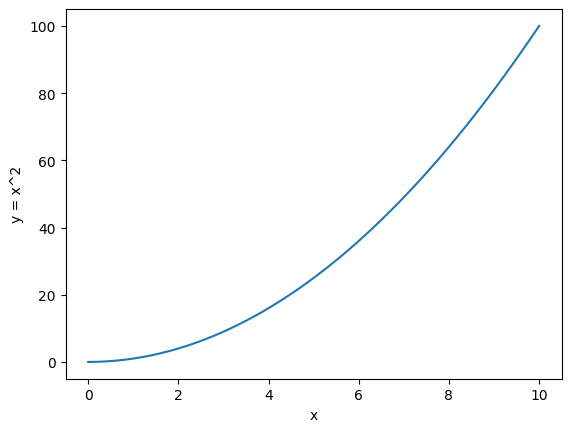

In [6]:
import numpy as np

x = np.linspace(0, 10, 50)
y = x**2

fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y = x^2')
plt.show()

`x` swept smoothly 0→10 — connecting each point to the next traces the actual curve. No zigzag.

**The rule:** `ax.scatter` for independent samples/rows. `ax.plot` for a swept or naturally ordered variable (continuous function, time series).

Polar plots for angular data, pie/stacked-bar for fractions of a whole — matching chart type to data type is a bigger design space, deferred for now.

> **Read more:** [PDSH — Simple Line Plots](https://jakevdp.github.io/PythonDataScienceHandbook/04.01-simple-line-plots.html)

# Histogram, done properly

`ax.hist` on the density column:

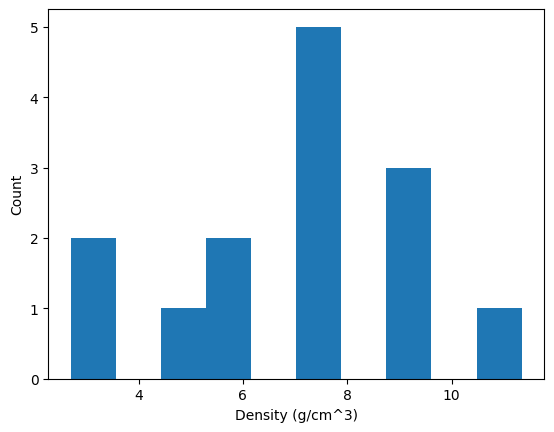

In [7]:
fig, ax = plt.subplots()
ax.hist(data['Density (g/cm^3)'])
ax.set_xlabel('Density (g/cm^3)')
ax.set_ylabel('Count')
plt.show()

Bins values, draws a bar per bin. 14 elements → default bin count looks chunky. Two `bins` choices side by side (a first taste of multi-panel `subplots`):

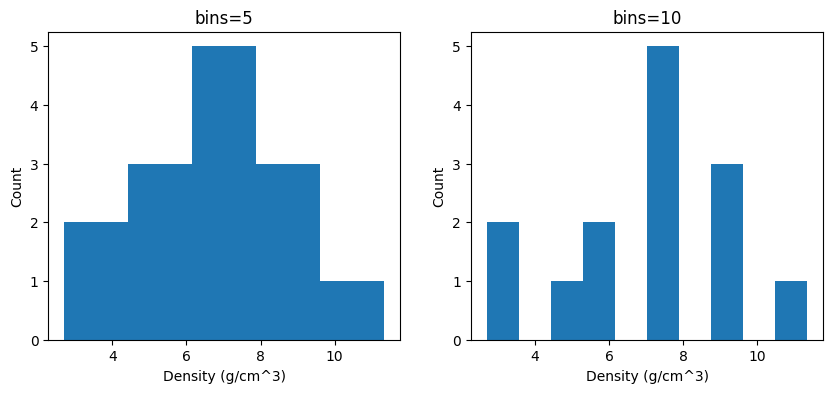

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(data['Density (g/cm^3)'], bins=5)
axes[0].set_xlabel('Density (g/cm^3)')
axes[0].set_ylabel('Count')
axes[0].set_title('bins=5')

axes[1].hist(data['Density (g/cm^3)'], bins=10)
axes[1].set_xlabel('Density (g/cm^3)')
axes[1].set_ylabel('Count')
axes[1].set_title('bins=10')
plt.show()

Same 14 numbers, two different-looking stories. With only 14 points, `bins=10` puts roughly one point per bin — those "gaps" are sampling noise, not structure. Neither picture is "wrong." More on "enough data" once we fit models, in Module 2.

`density=True` rescales bars so total **area** sums to 1 (not height) — useful comparing histograms from different sample sizes:

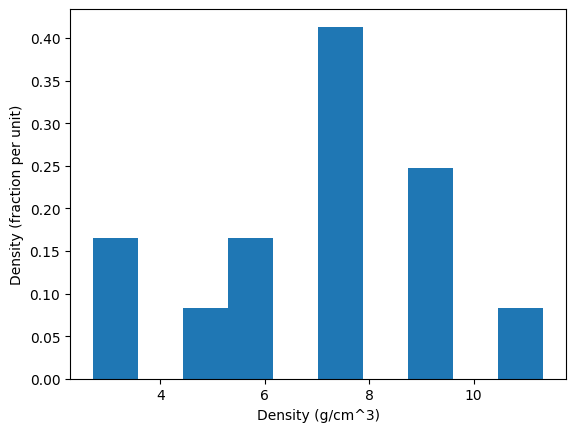

In [9]:
fig, ax = plt.subplots()
ax.hist(data['Density (g/cm^3)'], bins=10, density=True)
ax.set_xlabel('Density (g/cm^3)')
ax.set_ylabel('Density (fraction per unit)')
plt.show()

x-axis = whatever you're binning; y-axis = `Count` (or `Density`) — never leave it unlabeled.

# Multiple series and legends

*Do FCC metals sit in a different part of the plot than BCC/HCP?* Select rows by label (Lecture 8), by hand for now:

In [10]:
# We're picking rows by hand here (by row label, read off the table above) -- a better way,
# filtering by a *condition* instead of hardcoding row numbers, arrives in Lecture 11.
fcc = data.loc[[0, 1, 2]]        # Cu, Ni, Al
bcc_hcp = data.loc[[3, 6, 7, 8]]  # Zn, Ti, V, Cr
print(fcc)
print(bcc_hcp)
#
# Now plot both groups on the *same* `ax`, calling `ax.scatter` twice with a `label=` each time:

  Element  Standard Atomic Weight Atomic Radius Structure  Electronegativity  \
0      Cu                 63.5460      0.128 nm       FCC                1.8   
1      Ni                 58.6934      0.125 nm       FCC                1.8   
2      Al                 26.9810      0.143 nm       FCC                1.5   

  Valence  Melting Point (K)  Density (g/cm^3)  Heat of Fusion (kJ/mol)  \
0      2+            1357.77             8.960                    13.26   
1      2+            1728.00             8.908                    17.48   
2      3+             933.47             2.700                    10.71   

   Molar Heat Capacity (J/mol*K)  Young's Modulus (GPa)  Poisson Ratio  
0                          24.44                  119.0           0.34  
1                          26.07                  200.0           0.31  
2                          24.20                   70.0           0.35  
  Element  Standard Atomic Weight Atomic Radius Structure  Electronegativity  \
3     

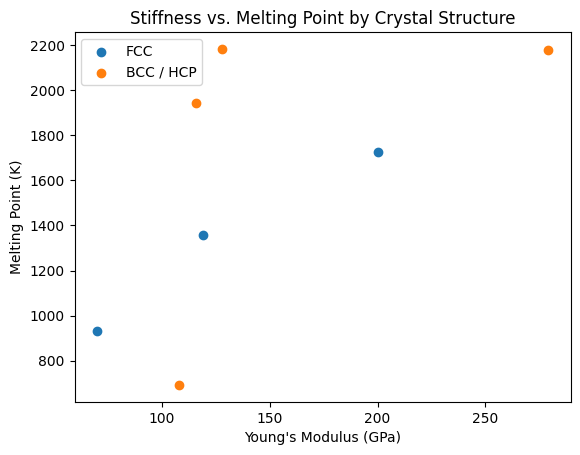

In [11]:
fig, ax = plt.subplots()
ax.scatter(fcc["Young's Modulus (GPa)"], fcc['Melting Point (K)'], label='FCC')
ax.scatter(bcc_hcp["Young's Modulus (GPa)"], bcc_hcp['Melting Point (K)'], label='BCC / HCP')
ax.set_xlabel("Young's Modulus (GPa)")
ax.set_ylabel('Melting Point (K)')
ax.set_title('Stiffness vs. Melting Point by Crystal Structure')
ax.legend()
plt.show()

`ax.legend()` draws the box — without it, `label=` does nothing. Legend explains what each *color* means, not the axes.

### [Check your understanding]

In the code cell below, build a two-series scatter plot comparing `Electronegativity` against
`Density (g/cm^3)` for the same two groups (`fcc` and `bcc_hcp` from above), with labels, a title, and
a legend.

# Subplots: multiple panels, no loops

*Stiffness-vs-melting scatter and density histogram, side by side?* `plt.subplots(rows, cols)` hands back `fig` plus `axes` — an `array` of `ax` objects.

`figsize=(10, 4)` — figure width/height in inches. Index into `axes` like any array (loops arrive Lecture 12):

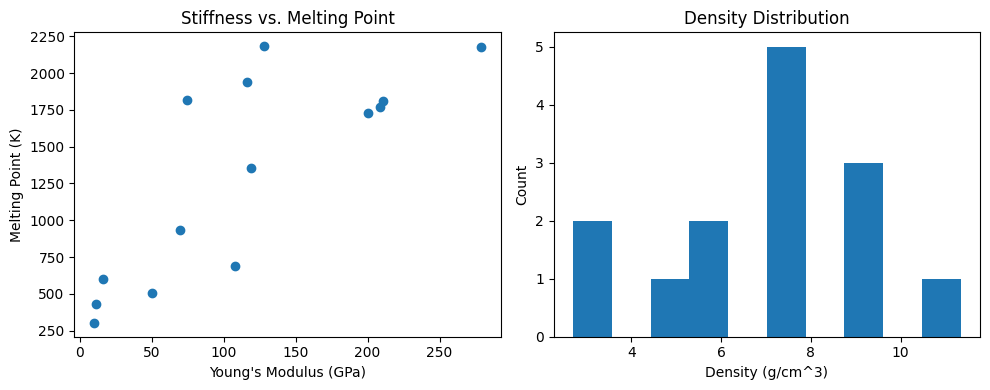

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data["Young's Modulus (GPa)"], data['Melting Point (K)'])
axes[0].set_xlabel("Young's Modulus (GPa)")
axes[0].set_ylabel('Melting Point (K)')
axes[0].set_title('Stiffness vs. Melting Point')

axes[1].hist(data['Density (g/cm^3)'], bins=10)
axes[1].set_xlabel('Density (g/cm^3)')
axes[1].set_ylabel('Count')
axes[1].set_title('Density Distribution')

plt.tight_layout()
plt.show()

Each panel configured independently — `axes[0]` never hears about `axes[1]`. `plt.tight_layout()` before `plt.show()` — cheap insurance against overlapping labels, every time you have more than one panel.

# Saving your figure

`plt.show()` displays; nothing saved to disk. `fig.savefig()`:

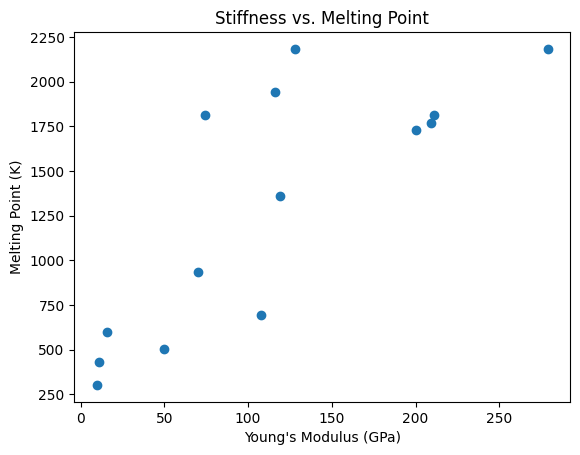

In [13]:
fig, ax = plt.subplots()
ax.scatter(data["Young's Modulus (GPa)"], data['Melting Point (K)'])
ax.set_xlabel("Young's Modulus (GPa)")
ax.set_ylabel('Melting Point (K)')
ax.set_title('Stiffness vs. Melting Point')

fig.savefig('stiffness_vs_melting.png', dpi=300, bbox_inches='tight')

* `dpi=300` — resolution. Low-`dpi` looks blurry printed or pasted into a report.
* `bbox_inches='tight'` — crops to fit everything drawn, including labels/title. Skip it and `savefig` can chop off a label.

### [Check your understanding]

In the code cell below, build a 1x2 `fig, axes` figure using `plt.subplots(1, 2, figsize=...)`:
* `axes[0]`: a scatter plot of `Electronegativity` (x) vs. `Standard Atomic Weight` (y), fully labeled
  with a title
* `axes[1]`: a histogram of `Poisson Ratio`, fully labeled with a title

Call `plt.tight_layout()`, then save the figure to `'my_first_figure.png'` with `dpi=300` and
`bbox_inches='tight'`.

Next time: same toolkit, pointed at a live pull from the Materials Project — much bigger table.